# 객체 탐지 비교 실습: R-CNN 계열 vs YOLO

**Faster R-CNN**과, **YOLO**를 같은 이미지에 직접 돌려보고, 속도·정확도·탐지 결과를 비교해봅시다 !

**실습 목표**
-  **추론 속도** 차이를 직접 측정
- 두 모델의 **탐지 결과(박스 개수, confidence, 위치 정확도)** 를 비교
- 결과를 바탕으로 **왜 성능이 다른지** 스스로 분석하고 답 작성

**⚠️ 시작 전에**: 상단 메뉴에서 `런타임(Runtime) → 런타임 유형 변경(Change runtime type) → 하드웨어 가속기: GPU` 로 설정하세요. GPU 없이도 실행되지만 속도 비교가 왜곡될 수 있습니다.


## 목차
1. 환경 설정
2. 샘플 이미지 준비
3. Faster R-CNN 실습
4. YOLO 실습
5. 정량적 비교: 속도
6. 정량적 비교: 탐지 결과
7. 여러 이미지로 확장 비교
8. 생각해보기 (실습 문제 + 답안 작성)


## 1. 환경 설정

`torchvision`은 Colab에 기본 설치되어 있어 Faster R-CNN을 바로 쓸 수 있습니다. YOLO는 `ultralytics` 패키지를 설치합니다.

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 27.0 MB/s eta 0:00:00


In [ ]:
import time
import urllib.request

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd
from PIL import Image

from ultralytics import YOLO

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
print("torch:", torch.__version__, "| torchvision:", torchvision.__version__)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
device: cuda
torch: 2.11.0+cu128 | torchvision: 0.26.0+cu128


## 2. 샘플 이미지 준비

사람·자전거·동물 등 다양한 크기와 개수의 객체가 담긴 이미지 몇 장을 받습니다. 자유롭게 다른 이미지 URL로 바꿔서 실험해보셔도 좋습니다 ! (특히 **작은 물체가 많은 이미지**, **물체가 겹친 이미지**를 추가해보면 두 모델의 차이가 더 잘 드러납니다).

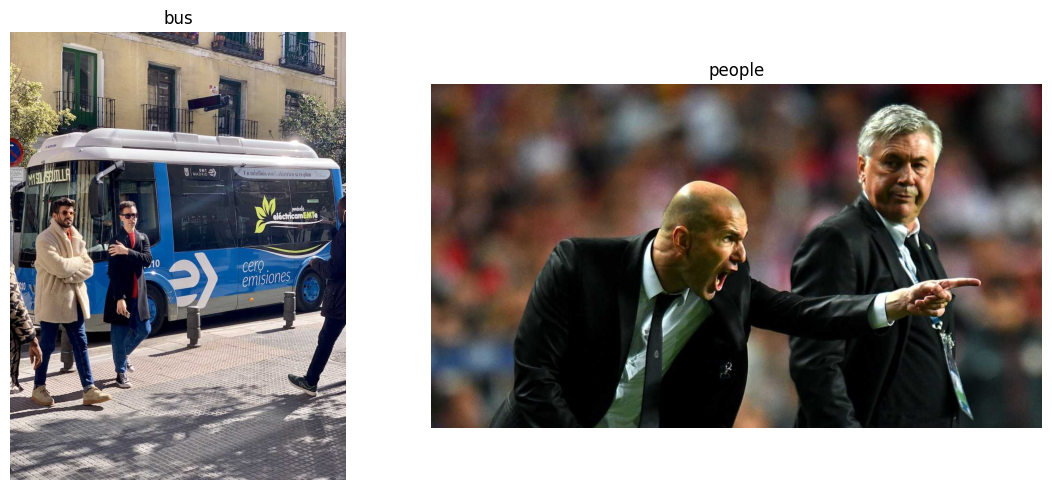

In [ ]:
IMAGE_URLS = {
    "bus": "https://ultralytics.com/images/bus.jpg",
    "people": "https://ultralytics.com/images/zidane.jpg",
}

image_paths = {}
for name, url in IMAGE_URLS.items():
    path = f"{name}.jpg"
    urllib.request.urlretrieve(url, path)
    image_paths[name] = path

fig, axes = plt.subplots(1, len(image_paths), figsize=(12, 5))
for ax, (name, path) in zip(axes, image_paths.items()):
    ax.imshow(Image.open(path))
    ax.set_title(name)
    ax.axis("off")
plt.tight_layout()
plt.show()


## 3. Faster R-CNN

In [ ]:
# COCO 클래스 이름 (torchvision 사전학습 모델 기준)
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A',
    'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
    'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
    'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass', 'cup', 'fork',
    'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli',
    'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch',
    'potted plant', 'bed', 'N/A', 'dining table', 'N/A', 'N/A', 'toilet', 'N/A',
    'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
    'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book', 'clock', 'vase',
    'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

# 사전학습된 Faster R-CNN (ResNet50 + FPN backbone) 로드
frcnn_model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
frcnn_model.to(device).eval()
print("Faster R-CNN 로드 완료")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


100%|██████████| 160M/160M [00:03<00:00, 49.6MB/s]


Faster R-CNN 로드 완료


In [ ]:
def run_faster_rcnn(image_path, score_threshold=0.6):
    """Faster R-CNN으로 추론하고 (박스, 라벨, 점수, 추론시간[초])을 반환"""
    img = Image.open(image_path).convert("RGB")
    tensor = torchvision.transforms.functional.to_tensor(img).to(device)

    with torch.no_grad():
        if device == "cuda":
            torch.cuda.synchronize()
        start = time.time()
        output = frcnn_model([tensor])[0]
        if device == "cuda":
            torch.cuda.synchronize()
        elapsed = time.time() - start

    keep = output["scores"] >= score_threshold
    boxes = output["boxes"][keep].cpu().numpy()
    labels = output["labels"][keep].cpu().numpy()
    scores = output["scores"][keep].cpu().numpy()
    return img, boxes, labels, scores, elapsed


def draw_boxes(ax, img, boxes, labels, scores, class_names, box_color="red"):
    ax.imshow(img)
    for box, label, score in zip(boxes, labels, scores):
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                  linewidth=2, edgecolor=box_color, facecolor="none")
        ax.add_patch(rect)
        name = class_names[label] if isinstance(class_names, list) else class_names.get(int(label), str(label))
        ax.text(x1, max(y1 - 5, 0), f"{name} {score:.2f}",
                 color="white", fontsize=8,
                 bbox=dict(facecolor=box_color, alpha=0.7, pad=1))
    ax.axis("off")


/tmp/ipykernel_1092/804980553.py:12: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/804980553.py:12: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/804980553.py:12: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/804980553.py:12: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/804980553.py:12: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/804980553.py:12: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/804980553.py:12: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(

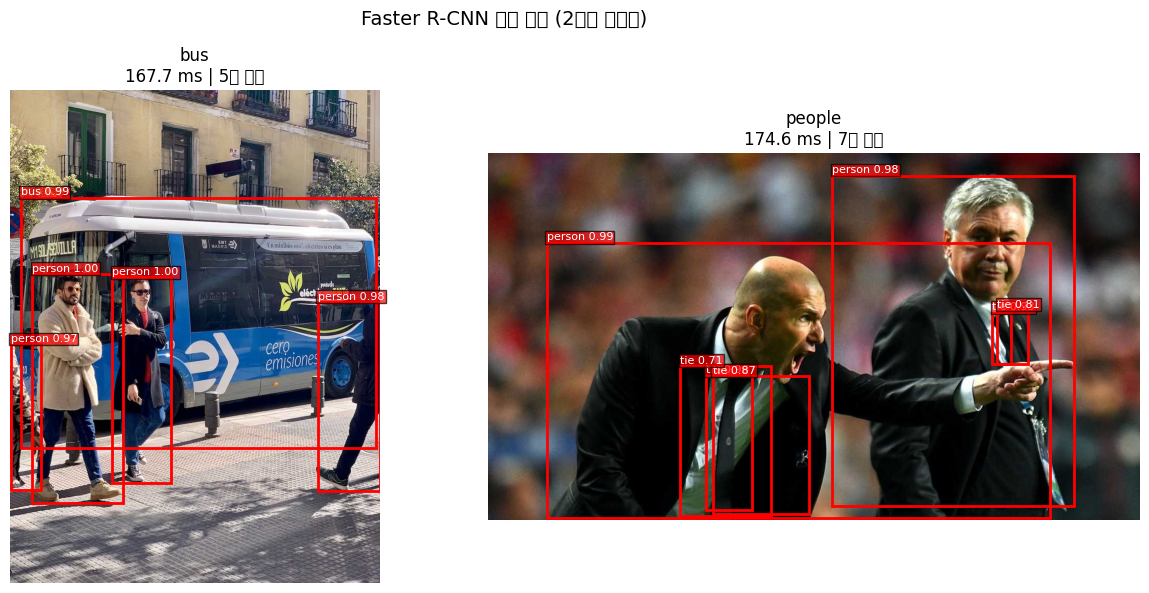

In [ ]:
# Faster R-CNN 워밍업 (첫 실행은 GPU 초기화 등으로 느리므로 측정에서 제외)
_ = run_faster_rcnn(list(image_paths.values())[0])

fig, axes = plt.subplots(1, len(image_paths), figsize=(13, 6))
frcnn_results = {}
for ax, (name, path) in zip(axes, image_paths.items()):
    img, boxes, labels, scores, elapsed = run_faster_rcnn(path)
    frcnn_results[name] = dict(boxes=boxes, labels=labels, scores=scores, time=elapsed)
    draw_boxes(ax, img, boxes, labels, scores, COCO_CLASSES, box_color="red")
    ax.set_title(f"{name}\n{elapsed*1000:.1f} ms | {len(boxes)}개 탐지")
plt.suptitle("Faster R-CNN 탐지 결과 (2단계 탐지기)", fontsize=14)
plt.tight_layout()
plt.show()


## 4. YOLO

모델은 원본 모델이 아닌 ultralytics에서 지원하는 YOLOv5 모델을 활용하겠습니다.

원하신다면 최신 모델은 yolov8도 해보시는 것을 추천드립니다 !

In [ ]:
yolo_model = YOLO("yolov5n.pt")  # nano 버전: 가장 가볍고 빠름
print("YOLOv5 로드 완료")

PRO TIP 💡 Replace 'model=yolov5n.pt' with new 'model=yolov5nu.pt'.
YOLOv5 'u' models are trained with https://github.com/ultralytics/ultralytics and feature improved performance vs standard YOLOv5 models trained with https://github.com/ultralytics/yolov5.
YOLOv5 로드 완료


In [ ]:
def run_yolo(image_path, conf_threshold=0.6):
    """YOLOv5로 추론하고 (박스, 라벨, 점수, 추론시간[초])을 반환"""
    if device == "cuda":
        torch.cuda.synchronize()
    start = time.time()
    results = yolo_model.predict(image_path, conf=conf_threshold, device=device, verbose=False)
    if device == "cuda":
        torch.cuda.synchronize()
    elapsed = time.time() - start

    r = results[0]
    boxes = r.boxes.xyxy.cpu().numpy()
    labels = r.boxes.cls.cpu().numpy().astype(int)
    scores = r.boxes.conf.cpu().numpy()
    img = Image.open(image_path).convert("RGB")
    return img, boxes, labels, scores, elapsed, r.names


/tmp/ipykernel_1092/3682511851.py:12: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3682511851.py:12: UserWarning: Glyph 53456 (\N{HANGUL SYLLABLE TAM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3682511851.py:12: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3682511851.py:12: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3682511851.py:12: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3682511851.py:12: UserWarning: Glyph 45800 (\N{HANGUL SYLLABLE DAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3682511851.py:12: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  plt.tight_

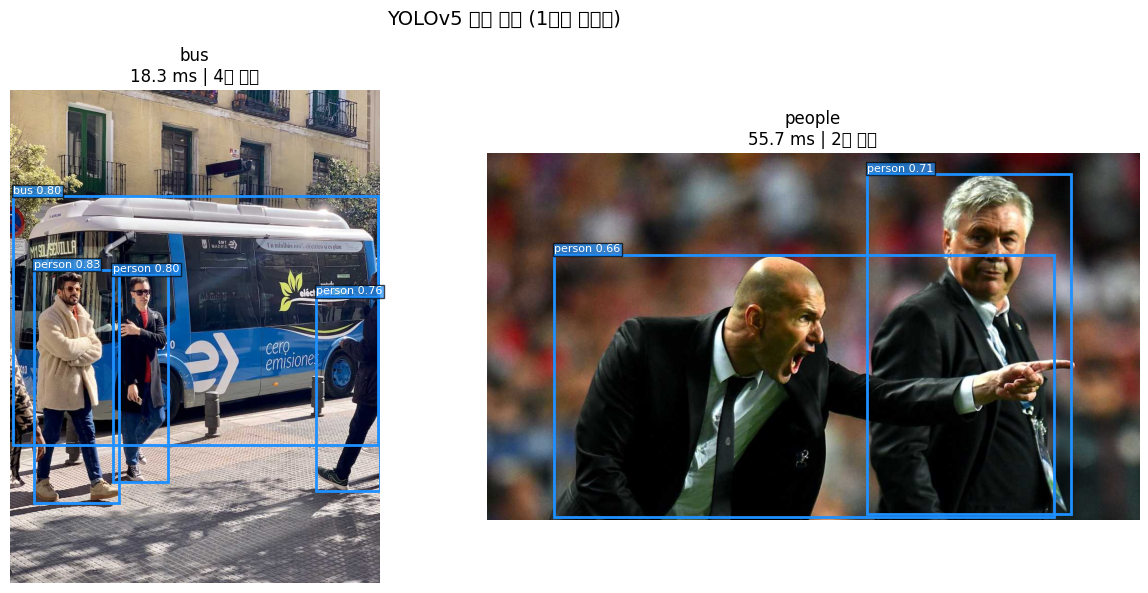

In [ ]:
# YOLO 워밍업
_ = run_yolo(list(image_paths.values())[0])

fig, axes = plt.subplots(1, len(image_paths), figsize=(13, 6))
yolo_results = {}
for ax, (name, path) in zip(axes, image_paths.items()):
    img, boxes, labels, scores, elapsed, names = run_yolo(path)
    yolo_results[name] = dict(boxes=boxes, labels=labels, scores=scores, time=elapsed)
    draw_boxes(ax, img, boxes, labels, scores, names, box_color="dodgerblue")
    ax.set_title(f"{name}\n{elapsed*1000:.1f} ms | {len(boxes)}개 탐지")
plt.suptitle("YOLOv5 탐지 결과 (1단계 탐지기)", fontsize=14)
plt.tight_layout()
plt.show()


## 5. 정량적 비교: 속도

한 번의 측정은 노이즈가 클 수 있으므로, 같은 이미지를 여러 번 반복 추론해 **평균 시간**을 비교합니다.

In [ ]:
N_RUNS = 20
speed_records = []

for name, path in image_paths.items():
    frcnn_times = [run_faster_rcnn(path)[4] for _ in range(N_RUNS)]
    yolo_times = [run_yolo(path)[4] for _ in range(N_RUNS)]
    speed_records.append({
        "image": name,
        "Faster R-CNN 평균(ms)": np.mean(frcnn_times) * 1000,
        "YOLOv5 평균(ms)": np.mean(yolo_times) * 1000,
    })

speed_df = pd.DataFrame(speed_records)
speed_df["속도 배율 (R-CNN / YOLO)"] = (
    speed_df["Faster R-CNN 평균(ms)"] / speed_df["YOLOv5 평균(ms)"]
).round(2)
speed_df


,image,Faster R-CNN 평균(ms),YOLOv5 평균(ms),속도 배율 (R-CNN / YOLO)
0,bus,100.561166,21.066201,4.77
1,people,112.234807,13.796055,8.14


/tmp/ipykernel_1092/3100812077.py:12: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3100812077.py:12: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3100812077.py:12: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3100812077.py:12: UserWarning: Glyph 47200 (\N{HANGUL SYLLABLE RON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3100812077.py:12: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3100812077.py:12: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1092/3100812077.py:12: UserWarning: Glyph 45230 (\N{HANGUL SYLLABLE NAJ}) missing from font(s) DejaVu Sans.
  plt.tight

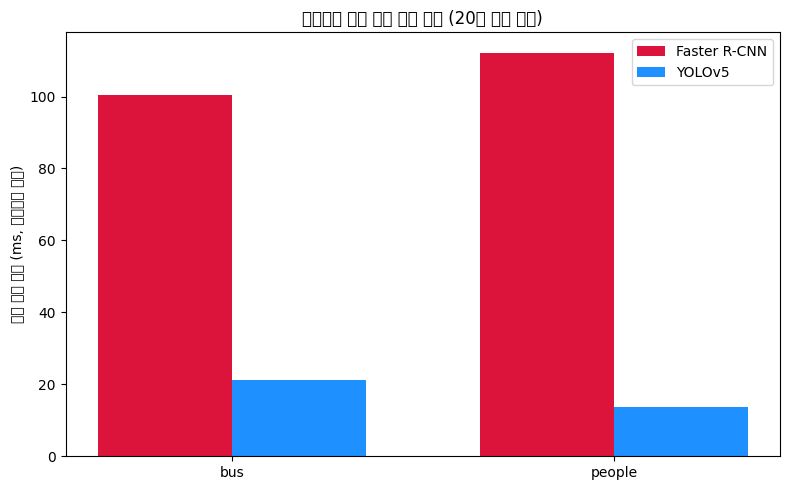

In [ ]:
x = np.arange(len(speed_df))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, speed_df["Faster R-CNN 평균(ms)"], width, label="Faster R-CNN", color="crimson")
ax.bar(x + width/2, speed_df["YOLOv5 평균(ms)"], width, label="YOLOv5", color="dodgerblue")
ax.set_xticks(x)
ax.set_xticklabels(speed_df["image"])
ax.set_ylabel("평균 추론 시간 (ms, 낮을수록 빠름)")
ax.set_title(f"이미지당 평균 추론 시간 비교 ({N_RUNS}회 반복 평균)")
ax.legend()
plt.tight_layout()
plt.show()


## 6. 정량적 비교: 탐지 결과

같은 이미지, 같은 confidence 임계값(0.6)에서 두 모델이 **몇 개의 물체를 찾았는지**, **평균 confidence는 얼마인지** 비교합니다.

In [ ]:
detect_records = []
for name, path in image_paths.items():
    f = frcnn_results[name]
    y = yolo_results[name]
    detect_records.append({
        "image": name,
        "R-CNN 탐지 개수": len(f["boxes"]),
        "YOLO 탐지 개수": len(y["boxes"]),
        "R-CNN 평균 confidence": round(float(np.mean(f["scores"])), 3) if len(f["scores"]) else None,
        "YOLO 평균 confidence": round(float(np.mean(y["scores"])), 3) if len(y["scores"]) else None,
    })

detect_df = pd.DataFrame(detect_records)
detect_df


,image,R-CNN 탐지 개수,YOLO 탐지 개수,R-CNN 평균 confidence,YOLO 평균 confidence
0,bus,5,4,0.988,0.798
1,people,7,2,0.893,0.682


## 8. 🧠 생각해보기 (실습 문제)

위에서 측정한 결과를 바탕으로 아래 질문에 직접 답을 작성해보세요 !

### Q1. 누가 더 빨랐나요 ? 속도 차이가 어느정도 나는지 적어주세요

**✏️ 답안 작성:**

>  80~90ms정도 차이로 YOLO가 더 빨랐다.


### Q2. 왜 Faster R-CNN이 YOLO보다 느릴까요?

두 모델의 **구조적 차이**를 바탕으로, 속도 차이가 발생하는 이유를 설명해보세요.

**✏️ 답안 작성:**

> YOLO는 2가지로 나뉘어있던 단계를 하나로 줄여 한번의 신경망 통과로 위치파악, 분류의 두가지 task를 처리할 수 있도록 하였다.


### Q3. 탐지 개수나 confidence에 차이가 있었나요?

**✏️ 답안 작성:**

> 탐지 개수와 confidence 모두 R-CNN이 높았다.


### Q4. 탐지 개수나 confidence에서 왜 차이가 나는지 고민해보고 답을 작성해주세요.

**📝 답안 작성:**

> YOLO는 속도를 크게 향상시키기 위해서 정밀하게 나뉘어진 두 단계를 통합하였다. 이 과정에서 후보영역을 정밀하게 뽑지 못하고 grid cell당 제한된 박스 수를 할당 받게 되었다. 작은 객체나 밀집 객체에 취약하다.


답변은 정답을 원하는게 아닙니다 ! 스스로 결과를 보고 왜 그렇게 나왔는지 고민해보고 편하게 작성해주세요 !! 그럼 오늘도 수고하셨습니다😊